# DongTing Dataset — Exploratory Analysis

A standalone EDA companion to `syscallad_dongting.ipynb`. The modeling
notebook focuses on classifier performance; this one drills into the data
itself to surface structure, class balance, vocabulary, leakage risks, and
embeddings — answering the question *what does this dataset actually look
like* before you decide how to model it.

**Source.** G. Duan et al., *"DongTing: A large-scale dataset for anomaly
detection of the Linux kernel,"* J. Syst. Softw. vol. 203, 2023.

**Collections in `syzbot_DB`:**

| Collection | n | Role |
|---|---|---|
| `kernel_syscallhook_bugpoc_trace_sum` | 12,116 | Attack — kernel bug PoCs from syzbot |
| `kernel_syscall_normal_strace`        |  6,850 | Normal — strace of benign test binaries |
| `kernel_convert_baseline`             | 18,966 | Unified labeled view + train/val/test split |

Outputs land in `outputs/eda/`.


## 1. Setup

In [1]:
import os, re, json, warnings, itertools
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

OUT = 'outputs/eda'; os.makedirs(OUT, exist_ok=True)
MONGO_URI = os.environ.get('MONGO_URI', 'mongodb://mongo:27017/')
MONGO_DB  = os.environ.get('MONGO_DB',  'syzbot_DB')

client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
db = client[MONGO_DB]
print('Mongo:', MONGO_URI, '→', MONGO_DB)
print('Collections:', db.list_collection_names())

PALETTE = {'Normal': '#4C72B0', 'Attack': '#DD8452'}


Mongo: mongodb://mongo:27017/ → syzbot_DB
Collections: ['kernel_syscallhook_bugpoc_trace_sum', 'kernel_syscall_normal_strace', 'kernel_convert_baseline']


## 2. Dataset Overview — counts, splits, class balance

Attack traces  : 12,116
Normal traces  : 6,850
Baseline rows  : 18,966  (18,966 expected = atk+nrm)
Class balance  : attack rate = 63.9%

Split × Label:
kcb_seq_lables   Attach  Normal
kcb_seq_class                  
DTDS-test          1633     678
DTDS-train         9356    5487
DTDS-validation    1127     685


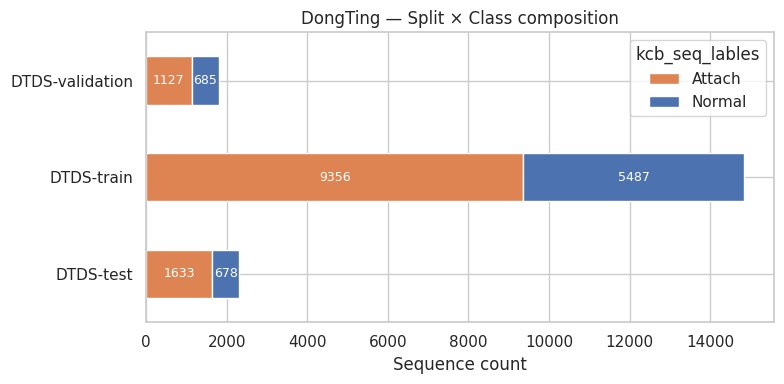

In [2]:
ATK = db['kernel_syscallhook_bugpoc_trace_sum']
NRM = db['kernel_syscall_normal_strace']
BL  = db['kernel_convert_baseline']

n_atk = ATK.estimated_document_count()
n_nrm = NRM.estimated_document_count()
n_bl  = BL.estimated_document_count()

print(f'Attack traces  : {n_atk:,}')
print(f'Normal traces  : {n_nrm:,}')
print(f'Baseline rows  : {n_bl:,}  ({n_atk + n_nrm:,} expected = atk+nrm)')
print(f'Class balance  : attack rate = {n_atk / (n_atk+n_nrm):.1%}')

# Split + label cross-tab
df_bl = pd.DataFrame(list(BL.find({}, {'kcb_seq_class': 1, 'kcb_seq_lables': 1, '_id': 0})))
split_lbl = (df_bl
             .groupby(['kcb_seq_class', 'kcb_seq_lables'])
             .size().unstack(fill_value=0))
print('\nSplit × Label:')
print(split_lbl)
split_lbl.to_csv(f'{OUT}/01_split_label.csv')

# Visualize split composition
fig, ax = plt.subplots(figsize=(8, 4))
split_lbl.plot(kind='barh', stacked=True, ax=ax,
               color=[PALETTE['Attack'], PALETTE['Normal']])
ax.set_xlabel('Sequence count'); ax.set_ylabel('')
ax.set_title('DongTing — Split × Class composition')
for c in ax.containers:
    ax.bar_label(c, label_type='center', fmt='%d', fontsize=9, color='white')
plt.tight_layout(); plt.savefig(f'{OUT}/01_split_composition.png', dpi=150); plt.show()


## 3. Kernel Version Distribution

The attack collection records the kernel version where each PoC was filed.
If a single kernel version dominates one class but not the other, a learner
could trivially exploit version as a feature → check before designing splits.


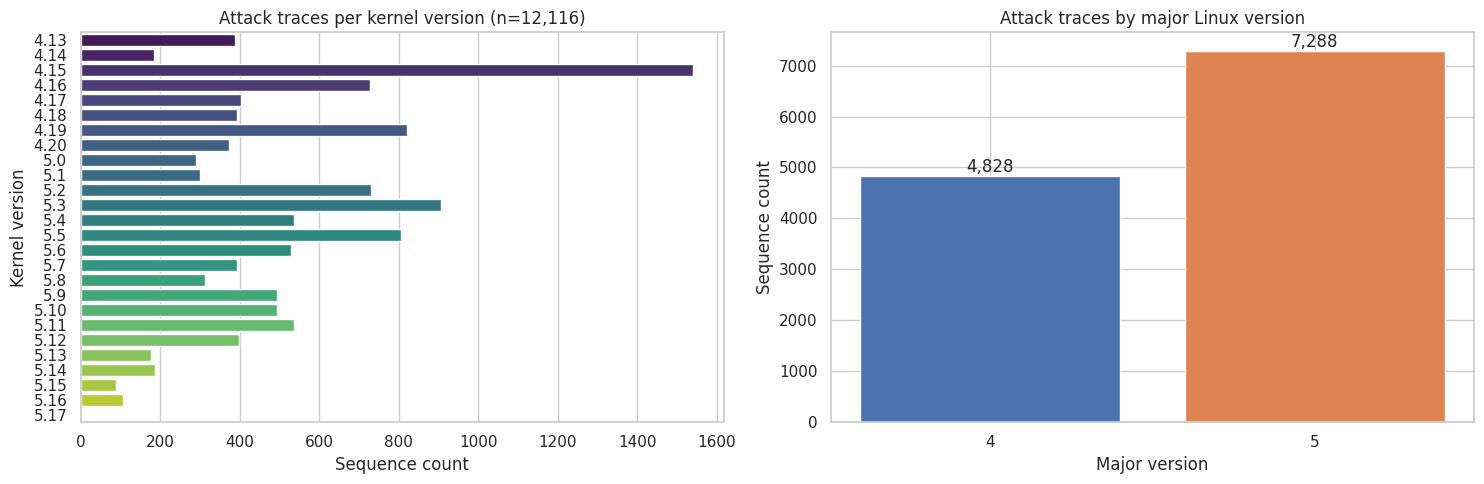

Distinct kernel versions: 26
Most-represented: 4.15 (1,540 traces, 12.7%)


In [3]:
kv_counts = Counter(d['kshs_kernel_ver']
                    for d in ATK.find({}, {'kshs_kernel_ver': 1}))
df_kv = (pd.Series(kv_counts, name='count')
         .sort_index().to_frame())
df_kv['major'] = [k.split('.')[0] for k in df_kv.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = sorted(df_kv.index, key=lambda v: tuple(int(x) for x in v.split('.')))
sns.barplot(x=df_kv.loc[order, 'count'].values, y=order, ax=axes[0],
            palette='viridis')
axes[0].set_xlabel('Sequence count'); axes[0].set_ylabel('Kernel version')
axes[0].set_title(f'Attack traces per kernel version (n={int(df_kv["count"].sum()):,})')

# Major-version rollup
maj = df_kv.groupby('major')['count'].sum().sort_index()
axes[1].bar(maj.index, maj.values, color=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_xlabel('Major version'); axes[1].set_ylabel('Sequence count')
axes[1].set_title('Attack traces by major Linux version')
for i, v in enumerate(maj.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout(); plt.savefig(f'{OUT}/02_kernel_versions.png', dpi=150); plt.show()
df_kv['count'].to_csv(f'{OUT}/02_kernel_versions.csv')
print(f'Distinct kernel versions: {df_kv.shape[0]}')
print(f'Most-represented: {df_kv["count"].idxmax()} '
      f'({df_kv["count"].max():,} traces, {df_kv["count"].max()/df_kv["count"].sum():.1%})')


## 4. Bug Category Taxonomy

syzbot bug names follow conventional prefixes that identify the *kind* of
defect: `KASAN__use_after_free`, `INFO__rcu_detected_stall`,
`general_protection_fault`, `WARNING__`, `BUG__`, etc.  Parsing the prefix
gives a free taxonomy of attack types beyond the binary attack/normal label.


Bug-category breakdown:
                          count   pct
KASAN                      2954  24.4
WARNING                    2633  21.7
general_protection_fault   1793  14.8
memory_leak                1485  12.3
possible_deadlock           823   6.8
BUG                         743   6.1
INFO                        712   5.9
KMSAN                       376   3.1
kernel_BUG                  213   1.8
other                       154   1.3
UBSAN                       106   0.9
inconsistent_lock_state      73   0.6
divide_error                 51   0.4


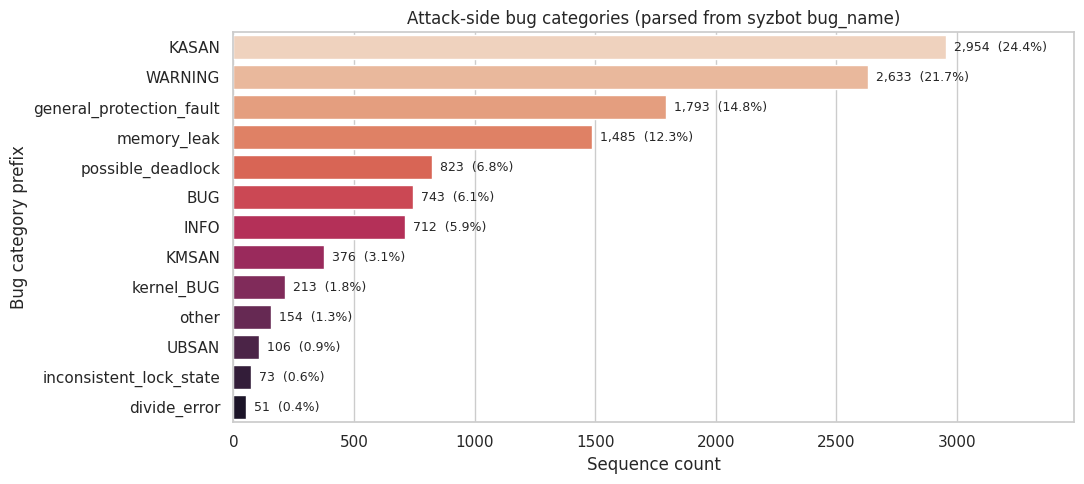


Sample bug names per category:
  [KASAN]
     KASAN__use_after_free_Read_in_rdma_listen_POC6
     KASAN__use_after_free_Read_in_tick_sched_handle__3__POC2
  [WARNING]
     WARNING_in_clear_standby_POC26
     WARNING_in_get_q_data
  [general_protection_fault]
     general_protection_fault_in_ax25cmp_POC1
     general_protection_fault_in_ax25cmp_POC13
  [memory_leak]
     memory_leak_in_bio_copy_user_iov_POC4
     memory_leak_in_internal_dev_create_POC33
  [possible_deadlock]
     possible_deadlock_in_userfaultfd_release_POC12
     possible_deadlock_in_flush_workqueue__2__POC13
  [BUG]
     BUG__MAX_STACK_TRACE_ENTRIES_too_low__POC13
     BUG__MAX_STACK_TRACE_ENTRIES_too_low__POC17
  [INFO]
     INFO__task_hung_in_vhost_net_stop_vq_POC1
     INFO__trying_to_register_non_static_key_in___flush_work_POC1
  [KMSAN]
     KMSAN__uninit_value_in_gue6_err__2__POC2
     KMSAN__uninit_value_in_gue_err_POC2


In [4]:
PREFIX_RE = re.compile(
    r'^(KASAN|UBSAN|INFO|WARNING|BUG|general_protection_fault|'
    r'kernel_BUG|divide_error|memory_leak|inconsistent_lock_state|'
    r'possible_deadlock|unable_to_handle_kernel|stack_segment|'
    r'KCSAN|KMSAN|task_hung|softirq_pending|panic|task)')

cat_counter = Counter()
bug_examples = defaultdict(list)
for d in ATK.find({}, {'kshs_poclog_name': 1}):
    name = d.get('kshs_poclog_name', '')
    m = PREFIX_RE.match(name)
    cat = m.group(1) if m else 'other'
    cat_counter[cat] += 1
    if len(bug_examples[cat]) < 3:
        bug_examples[cat].append(name)

df_cat = (pd.Series(cat_counter, name='count')
          .sort_values(ascending=False).to_frame())
df_cat['pct'] = (df_cat['count'] / df_cat['count'].sum() * 100).round(1)
print('Bug-category breakdown:')
print(df_cat.to_string())
df_cat.to_csv(f'{OUT}/03_bug_categories.csv')

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=df_cat['count'].values, y=df_cat.index, ax=ax, palette='rocket_r')
for i, (c, p) in enumerate(zip(df_cat['count'], df_cat['pct'])):
    ax.text(c, i, f'  {c:,}  ({p}%)', va='center', fontsize=9)
ax.set_xlabel('Sequence count'); ax.set_ylabel('Bug category prefix')
ax.set_title('Attack-side bug categories (parsed from syzbot bug_name)')
ax.set_xlim(0, df_cat['count'].max() * 1.18)
plt.tight_layout(); plt.savefig(f'{OUT}/03_bug_categories.png', dpi=150); plt.show()

print('\nSample bug names per category:')
for cat in df_cat.index[:8]:
    print(f'  [{cat}]')
    for ex in bug_examples[cat][:2]:
        print(f'     {ex}')


## 5. Sequence Length Analysis

`kshs_bugpoc_syscall_counts` / `kns_normal_seq_counts` record the syscall
count per trace.  Heavy tails or class-specific clustering directly affect
windowing / padding choices in downstream modeling.


class       Attack      Normal
count      12116.0      6850.0
mean     1022001.8     16051.8
std      4665157.2    233082.3
min            1.0         1.0
10%           30.0        35.0
25%           31.0        42.0
50%           45.0        61.0
75%         8301.0       127.0
90%       596076.5       302.0
99%     21034347.3    241817.4
max    100000000.0  14397021.0


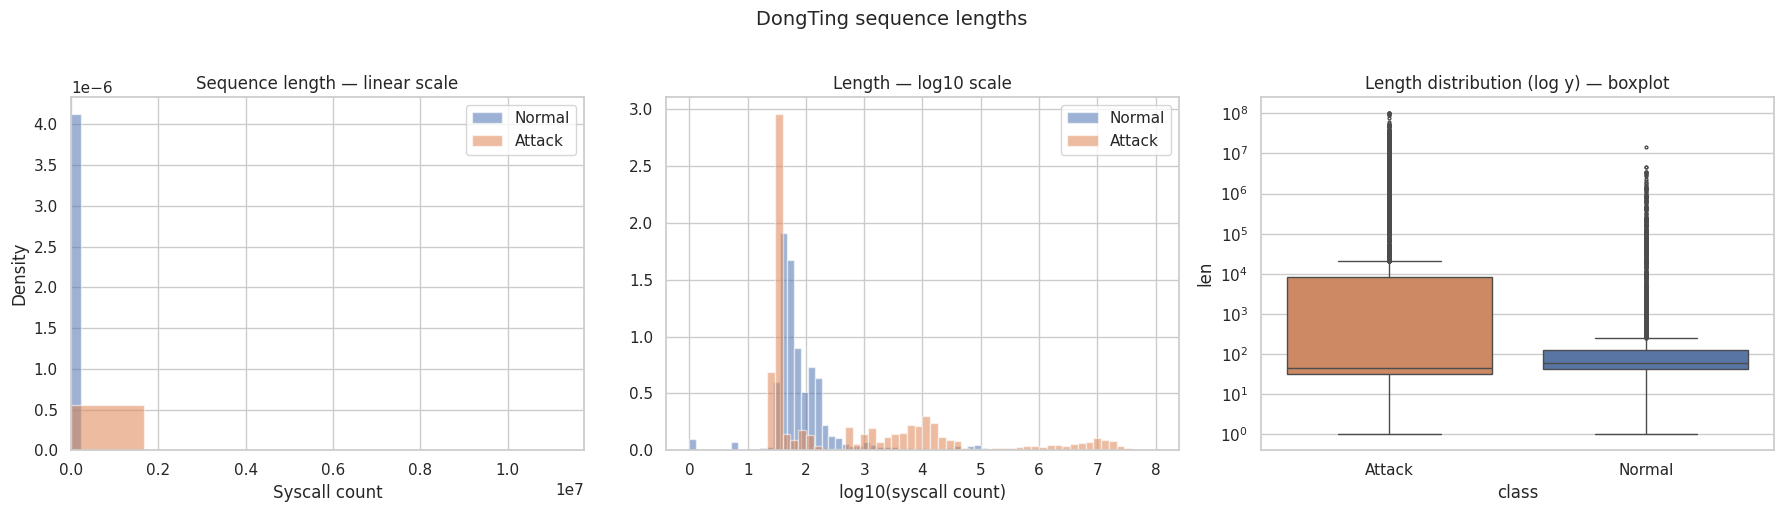


Longest 10 traces (any class):
 class       len
Attack 100000000
Attack 100000000
Attack 100000000
Attack  99998968
Attack  97309038
Attack  92502759
Attack  92032769
Attack  77028763
Attack  59268103
Attack  53707368


In [5]:
lens = []
for d in ATK.find({}, {'kshs_bugpoc_syscall_counts': 1}):
    lens.append(('Attack', int(d['kshs_bugpoc_syscall_counts'])))
for d in NRM.find({}, {'kns_normal_seq_counts': 1}):
    lens.append(('Normal', int(d['kns_normal_seq_counts'])))
df_len = pd.DataFrame(lens, columns=['class', 'len'])

print(df_len.groupby('class')['len'].describe(
    percentiles=[.1, .25, .5, .75, .9, .99]).T.round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for cls, color in PALETTE.items():
    sub = df_len.loc[df_len['class'] == cls, 'len']
    axes[0].hist(sub, bins=60, alpha=0.55, color=color, label=cls, density=True)
axes[0].set_xlabel('Syscall count'); axes[0].set_ylabel('Density')
axes[0].set_title('Sequence length — linear scale'); axes[0].legend()
axes[0].set_xlim(0, df_len['len'].quantile(0.98))

for cls, color in PALETTE.items():
    sub = df_len.loc[df_len['class'] == cls, 'len']
    axes[1].hist(np.log10(sub.clip(lower=1)), bins=60, alpha=0.55,
                 color=color, label=cls, density=True)
axes[1].set_xlabel('log10(syscall count)'); axes[1].set_title('Length — log10 scale'); axes[1].legend()

sns.boxplot(data=df_len, x='class', y='len', ax=axes[2],
            palette=PALETTE, fliersize=2)
axes[2].set_yscale('log')
axes[2].set_title('Length distribution (log y) — boxplot')

plt.suptitle('DongTing sequence lengths', fontsize=14, y=1.02)
plt.tight_layout(); plt.savefig(f'{OUT}/04_seq_length.png', dpi=150); plt.show()
df_len.to_csv(f'{OUT}/04_seq_length.csv', index=False)

# Top-N longest traces — sanity check for outliers
top = df_len.nlargest(10, 'len')
print('\nLongest 10 traces (any class):')
print(top.to_string(index=False))


## 6. Syscall Vocabulary

How rich is the syscall vocabulary on each side?  We tokenize the
pipe-delimited sequences and count distinct + most-frequent syscalls per class.


Distinct syscalls — Attack: 1146  Normal:  334  Union: 1304
Total tokens   — Attack: 422,027,574  Normal: 49,336,043

Attack-only syscalls (970): ['eventfd', 'fork', 'get_mempolicy', 'kexec_load', 'mbind', 'migrate_pages', 'mknod', 'nanosleep', 'pkey_mprotect', 'restart_syscall', 'seccomp', 'semop', 'set_mempolicy', 'setrlimit', 'sy_BUG__Bad_rss_counter_state__3__POC10.log', 'sy_BUG__Bad_rss_counter_state__3__POC11.log', 'sy_BUG__Bad_rss_counter_state__3__POC12.log', 'sy_BUG__Bad_rss_counter_state__3__POC5.log', 'sy_BUG__Bad_rss_counter_state__3__POC6.log', 'sy_BUG__Bad_rss_counter_state__3__POC7.log', 'sy_BUG__Bad_rss_counter_state__3__POC8.log', 'sy_BUG__Bad_rss_counter_state__3__POC9.log', 'sy_BUG__MAX_LOCKDEP_CHAIN_HLOCKS_too_low__POC18.log', 'sy_BUG__corrupted_list_in____neigh_create_POC2.log', 'sy_BUG__corrupted_list_in____neigh_create_POC5.log']
Normal-only syscalls (158): ['_sysctl', 'adjtimex', 'alarm', 'clock_getres', 'clock_settime', 'clone3', 'close_range', 'copy_file_range

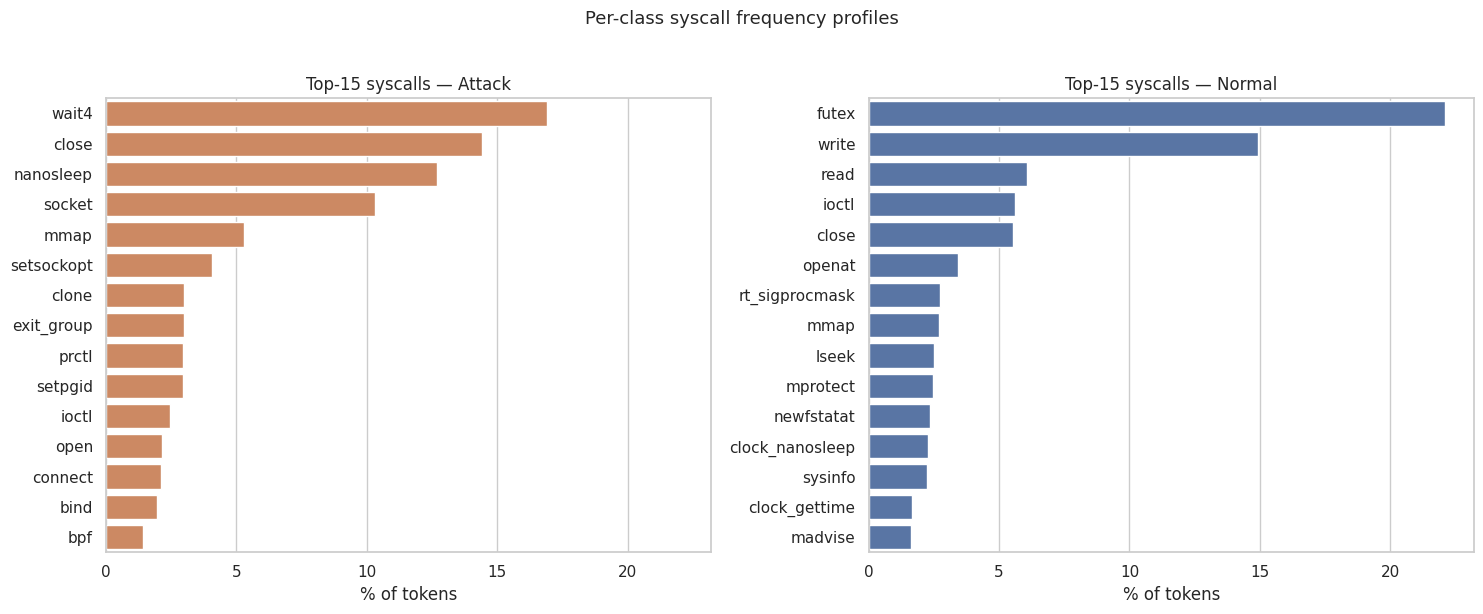

In [6]:
def iter_tokens(field, cursor):
    for d in cursor:
        seq = d.get(field, '')
        if seq:
            for tok in seq.split('|'):
                t = tok.strip()
                if t:
                    yield t

atk_tok_counts = Counter(iter_tokens('kshs_bugpoc_syscall_list',
                                     ATK.find({}, {'kshs_bugpoc_syscall_list': 1})))
nrm_tok_counts = Counter(iter_tokens('kns_normal_seq_list',
                                     NRM.find({}, {'kns_normal_seq_list': 1})))

print(f'Distinct syscalls — Attack: {len(atk_tok_counts):>4}  '
      f'Normal: {len(nrm_tok_counts):>4}  '
      f'Union: {len(set(atk_tok_counts) | set(nrm_tok_counts)):>4}')
print(f'Total tokens   — Attack: {sum(atk_tok_counts.values()):>10,}  '
      f'Normal: {sum(nrm_tok_counts.values()):>10,}')

attack_only = set(atk_tok_counts) - set(nrm_tok_counts)
normal_only = set(nrm_tok_counts) - set(atk_tok_counts)
print(f'\nAttack-only syscalls ({len(attack_only)}): {sorted(attack_only)[:25]}')
print(f'Normal-only syscalls ({len(normal_only)}): {sorted(normal_only)[:25]}')

# Top-K per side
df_voc = pd.DataFrame({
    'attack_count': atk_tok_counts,
    'normal_count': nrm_tok_counts,
}).fillna(0).astype(int)
df_voc['attack_share'] = df_voc['attack_count'] / df_voc['attack_count'].sum()
df_voc['normal_share'] = df_voc['normal_count'] / df_voc['normal_count'].sum()
df_voc['diff_share']   = df_voc['attack_share'] - df_voc['normal_share']

top_atk = df_voc.nlargest(15, 'attack_share').index.tolist()
top_nrm = df_voc.nlargest(15, 'normal_share').index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)
sns.barplot(x=df_voc.loc[top_atk, 'attack_share'] * 100,
            y=top_atk, ax=axes[0], color=PALETTE['Attack'])
axes[0].set_xlabel('% of tokens'); axes[0].set_title('Top-15 syscalls — Attack')

sns.barplot(x=df_voc.loc[top_nrm, 'normal_share'] * 100,
            y=top_nrm, ax=axes[1], color=PALETTE['Normal'])
axes[1].set_xlabel('% of tokens'); axes[1].set_title('Top-15 syscalls — Normal')

plt.suptitle('Per-class syscall frequency profiles', y=1.02, fontsize=13)
plt.tight_layout(); plt.savefig(f'{OUT}/05_vocab_top.png', dpi=150); plt.show()
df_voc.to_csv(f'{OUT}/05_vocab.csv')


## 7. Discriminative Syscalls — Δ-share + log-odds

`diff_share` is a quick "more attack than normal" indicator, but raw shares
are biased by total volume.  Smoothed **log-odds** (à la Monroe-Colaresi-Quinn)
is robust to vocabulary size differences.


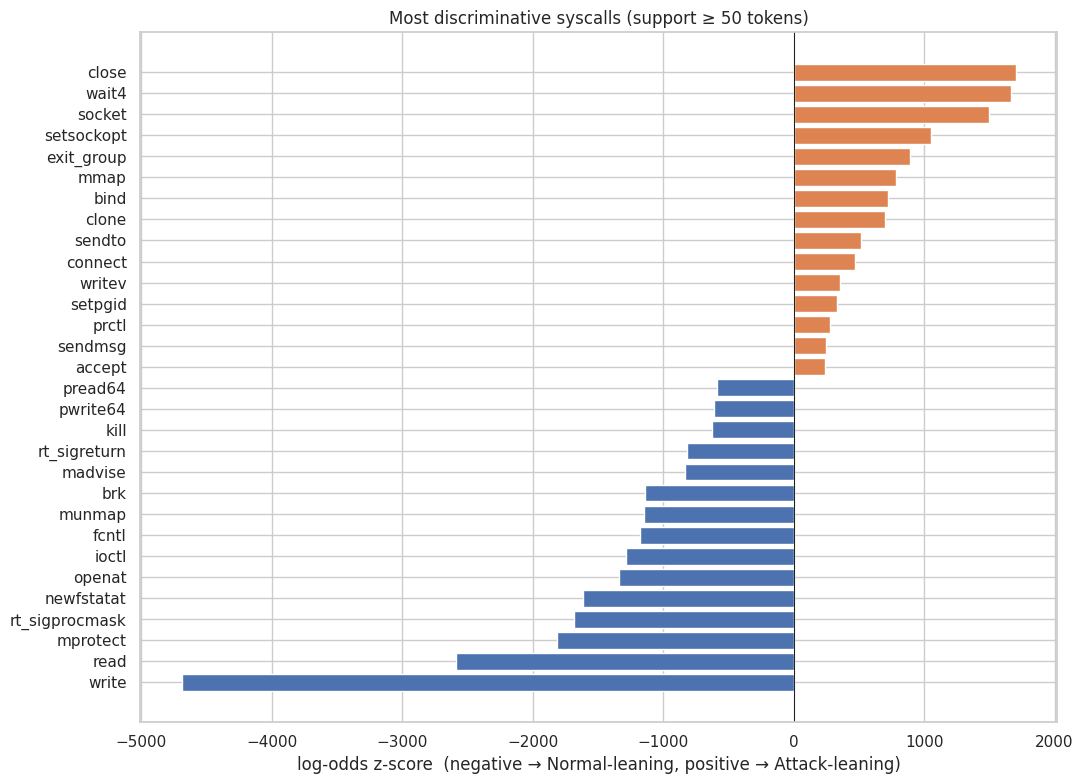

Top attack-leaning:
            attack_count  normal_count   log_odds_z
close           60760825       2737915  1702.287754
wait4           71407963        164832  1665.443409
socket          43521335        206472  1500.066655
setsockopt      17183017        239152  1051.404438
exit_group      12579592        161720   892.885759
mmap            22312606       1335142   781.850452
bind             8277234        123813   724.166737
clone           12625219        595354   698.313465
sendto           5986966        241247   517.438739
connect          8856079        537373   474.058923
writev           3475605        168156   355.271183
setpgid         12463932          2770   331.308355
prctl           12468299          1646   276.548852
sendmsg          2812605        179680   249.586593
accept           1545483         72852   240.144396

Top normal-leaning:
                attack_count  normal_count   log_odds_z
write                3550289       7373130 -4691.505758
read           

In [7]:
# Smoothed log-odds: log( (c_a + α) / (N_a + αV - c_a) ) - log normal counterpart
ALPHA = 0.5
V = df_voc.shape[0]
Na = df_voc['attack_count'].sum()
Nn = df_voc['normal_count'].sum()

ca, cn = df_voc['attack_count'].values, df_voc['normal_count'].values
lo_a = np.log((ca + ALPHA) / (Na + ALPHA*V - ca + 1))
lo_n = np.log((cn + ALPHA) / (Nn + ALPHA*V - cn + 1))
df_voc['log_odds'] = lo_a - lo_n

# z-score by variance of log odds difference  (approximation: 1/(c+α) + 1/(N-c+α))
var = 1/(ca + ALPHA) + 1/(cn + ALPHA)
df_voc['log_odds_z'] = df_voc['log_odds'] / np.sqrt(var)

# Filter to syscalls with at least some support to avoid noise
support = (df_voc['attack_count'] + df_voc['normal_count']) >= 50
df_disc = df_voc[support].sort_values('log_odds_z')

top_attack = df_disc.tail(15)
top_normal = df_disc.head(15)

fig, ax = plt.subplots(figsize=(11, 8))
both = pd.concat([top_normal, top_attack])
colors = ([PALETTE['Normal']] * len(top_normal)) + ([PALETTE['Attack']] * len(top_attack))
ax.barh(range(len(both)), both['log_odds_z'].values, color=colors)
ax.set_yticks(range(len(both))); ax.set_yticklabels(both.index)
ax.axvline(0, color='k', lw=0.7)
ax.set_xlabel('log-odds z-score  (negative → Normal-leaning, positive → Attack-leaning)')
ax.set_title('Most discriminative syscalls (support ≥ 50 tokens)')
plt.tight_layout(); plt.savefig(f'{OUT}/06_discriminative_syscalls.png', dpi=150); plt.show()

print('Top attack-leaning:'); print(top_attack[['attack_count','normal_count','log_odds_z']].iloc[::-1])
print('\nTop normal-leaning:'); print(top_normal[['attack_count','normal_count','log_odds_z']])


## 8. Bigram & Trigram Patterns

Single syscalls miss *control flow*.  We compare top bigrams/trigrams across
classes — these are often what feature engineers eventually encode.


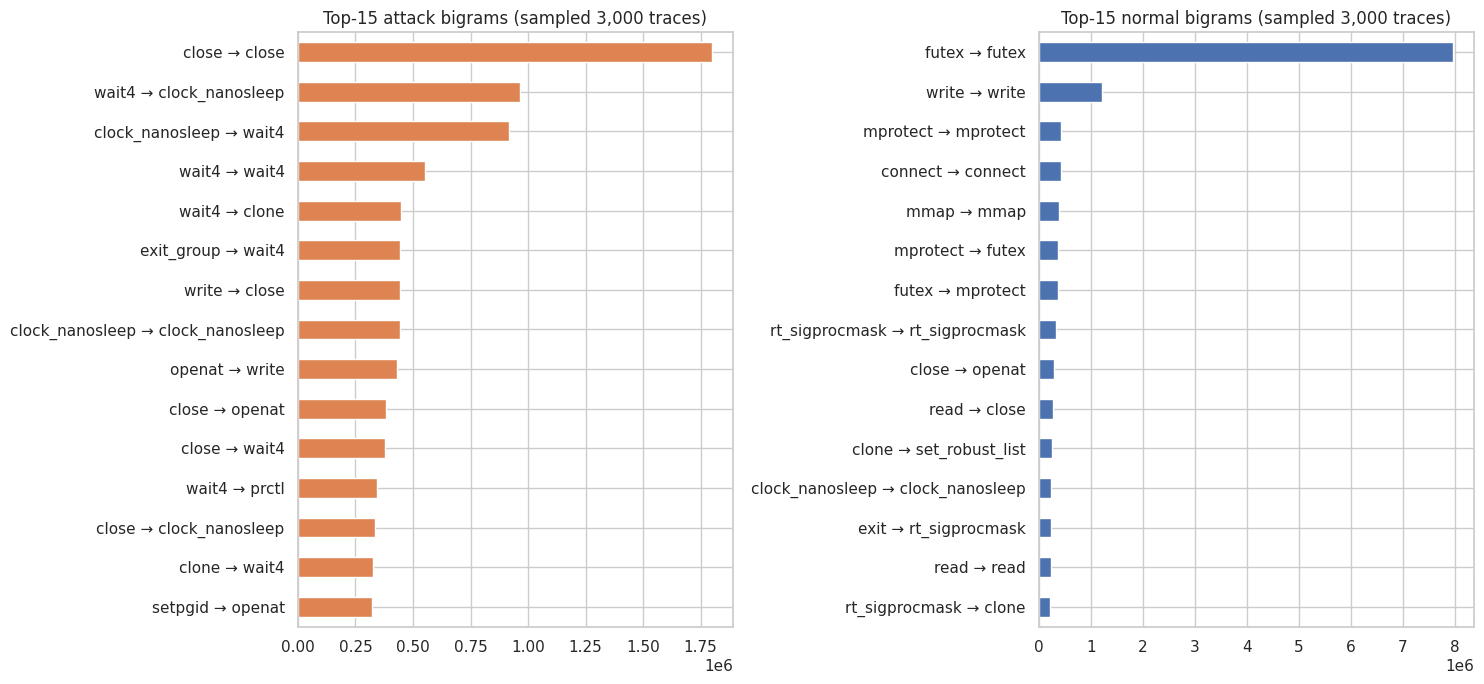

Top attack-leaning bigrams:
                           bigram  attack  normal          z
               exit_group → wait4  443917    1542 230.215060
                  openat → openat  120630    5078 234.359689
                    clone → wait4  324881    5247 310.996684
clock_nanosleep → clock_nanosleep  443174  238228 322.074569
                    close → wait4  379495   11104 388.117320
                    wait4 → clone  448043   10137 398.068995
                    wait4 → close  316487   29032 422.222176
                   openat → write  429282   32357 484.378678
                    write → close  443523   32905 491.655858
                    close → close 1800497   84363 952.322871

Top normal-leaning bigrams:
                 bigram  attack  normal           z
          write → write   39307 1215439 -645.941924
            mmap → mmap   12259  376529 -355.316437
    mprotect → mprotect    5988  432330 -316.551245
    openat → newfstatat   12469  197653 -280.527805
      connec

In [8]:
def ngrams(tokens, n):
    return zip(*[tokens[i:] for i in range(n)])

def class_ngrams(coll, field, n, limit=None):
    cnt = Counter()
    cur = coll.find({}, {field: 1})
    if limit: cur = cur.limit(limit)
    for d in cur:
        seq = d.get(field, '')
        if not seq: continue
        toks = [t for t in seq.split('|') if t]
        cnt.update(ngrams(toks, n))
    return cnt

# Limit attack pull for runtime; sample is representative for top-K bigrams
NGRAM_LIMIT = 3000
bg_a = class_ngrams(ATK, 'kshs_bugpoc_syscall_list', 2, limit=NGRAM_LIMIT)
bg_n = class_ngrams(NRM, 'kns_normal_seq_list',      2, limit=NGRAM_LIMIT)

def top_ngrams(cnt, k=15):
    return pd.Series({' → '.join(ng): c for ng, c in cnt.most_common(k)})

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
top_ngrams(bg_a).iloc[::-1].plot.barh(ax=axes[0], color=PALETTE['Attack'])
axes[0].set_title(f'Top-15 attack bigrams (sampled {NGRAM_LIMIT:,} traces)')
top_ngrams(bg_n).iloc[::-1].plot.barh(ax=axes[1], color=PALETTE['Normal'])
axes[1].set_title(f'Top-15 normal bigrams (sampled {NGRAM_LIMIT:,} traces)')
plt.tight_layout(); plt.savefig(f'{OUT}/07_bigrams.png', dpi=150); plt.show()

# Discriminative bigrams via log-odds
all_keys = set(bg_a) | set(bg_n)
rows = []
Na2, Nn2 = sum(bg_a.values()), sum(bg_n.values())
V2 = len(all_keys)
for k in all_keys:
    a, b = bg_a.get(k, 0), bg_n.get(k, 0)
    if a + b < 50: continue
    lo = np.log((a+ALPHA)/(Na2+ALPHA*V2-a+1)) - np.log((b+ALPHA)/(Nn2+ALPHA*V2-b+1))
    z  = lo / np.sqrt(1/(a+ALPHA) + 1/(b+ALPHA))
    rows.append({'bigram': ' → '.join(k), 'attack': a, 'normal': b, 'z': z})
df_bg = pd.DataFrame(rows).sort_values('z')
print('Top attack-leaning bigrams:'); print(df_bg.tail(10).to_string(index=False))
print('\nTop normal-leaning bigrams:'); print(df_bg.head(10).to_string(index=False))
df_bg.to_csv(f'{OUT}/07_discriminative_bigrams.csv', index=False)


## 9. Kernel-Version × Class — Leakage Check

If specific kernel versions appear only in one class, the model can pick up
version as a shortcut.  We compute the kernel-version distribution side by
side. (Normal traces don't carry a kernel version, so we focus on whether
the *attack* distribution is uniform across versions — a uniform/wide
distribution is healthy.)


Kernel-version diversity (Gini-Simpson): 0.944  (1 = uniform; 0 = single version)
Top-3 versions account for 27.0% of attacks


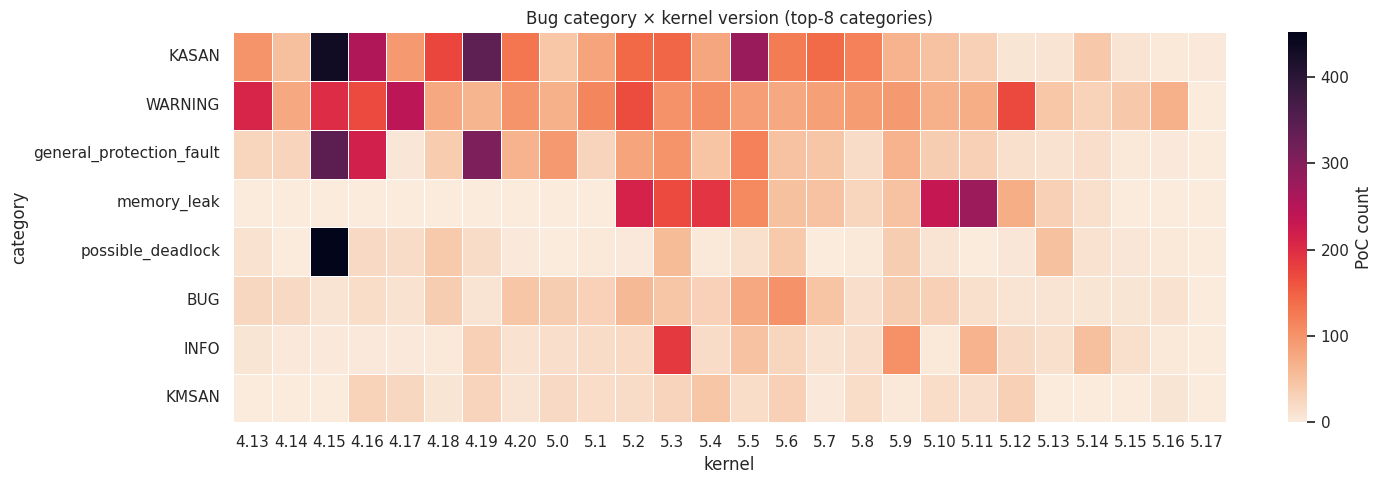

In [9]:
# Attack share concentration — Gini-style
shares = df_kv['count'].values / df_kv['count'].sum()
gini = 1 - (shares ** 2).sum()   # Gini-Simpson diversity (higher = more spread)
print(f'Kernel-version diversity (Gini-Simpson): {gini:.3f}  '
      f'(1 = uniform; 0 = single version)')
print(f'Top-3 versions account for {shares[np.argsort(-shares)[:3]].sum():.1%} of attacks')

# Distribution by bug category to see if specific bugs cluster on specific kernels
sample_bugs = []
for d in ATK.find({}, {'kshs_poclog_name': 1, 'kshs_kernel_ver': 1}):
    m = PREFIX_RE.match(d.get('kshs_poclog_name', ''))
    sample_bugs.append({
        'category': m.group(1) if m else 'other',
        'kernel': d['kshs_kernel_ver'],
    })
df_cb = pd.DataFrame(sample_bugs)
heat = (df_cb.groupby(['category', 'kernel']).size().unstack(fill_value=0))
top_cats = df_cat.index[:8].tolist()
heat = heat.loc[[c for c in top_cats if c in heat.index]]
heat = heat.reindex(columns=sorted(heat.columns,
                                   key=lambda v: tuple(int(x) for x in v.split('.'))))

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(heat, cmap='rocket_r', annot=False, cbar_kws={'label': 'PoC count'},
            ax=ax, linewidths=0.4)
ax.set_title('Bug category × kernel version (top-8 categories)')
plt.tight_layout(); plt.savefig(f'{OUT}/08_category_kernel_heatmap.png', dpi=150); plt.show()
heat.to_csv(f'{OUT}/08_category_kernel.csv')


## 10. Bag-of-Syscalls Embedding (PCA + UMAP)

Project each trace into a frequency vector over the top-K syscalls, then
reduce to 2D for a qualitative look at class separability and any
sub-cluster structure inside attacks.


In [10]:
# Build vocab limited to top-K (controls dim + runtime)
TOPK = 80
top_voc = df_voc.nlargest(TOPK, lambda c: 'attack_count')  # placeholder
top_voc = df_voc[['attack_count', 'normal_count']].sum(axis=1).nlargest(TOPK).index.tolist()
vocab = {tok: i for i, tok in enumerate(top_voc)}
print(f'Embedding dim = {len(vocab)}')

def vectorize(seq):
    v = np.zeros(len(vocab), dtype=np.float32)
    for t in seq.split('|'):
        if t in vocab:
            v[vocab[t]] += 1
    s = v.sum()
    return v / s if s > 0 else v   # L1 normalize → frequency vector

X, y, cat = [], [], []
for d in ATK.find({}, {'kshs_bugpoc_syscall_list': 1, 'kshs_poclog_name': 1}):
    X.append(vectorize(d.get('kshs_bugpoc_syscall_list', '')))
    y.append(1)
    m = PREFIX_RE.match(d.get('kshs_poclog_name', ''))
    cat.append(m.group(1) if m else 'other')
for d in NRM.find({}, {'kns_normal_seq_list': 1}):
    X.append(vectorize(d.get('kns_normal_seq_list', '')))
    y.append(0); cat.append('normal')

X = np.array(X); y = np.array(y); cat = np.array(cat)
print(f'X shape: {X.shape}')


Embedding dim = 80


X shape: (18966, 80)


PCA explained variance: 13.1% (2 components)


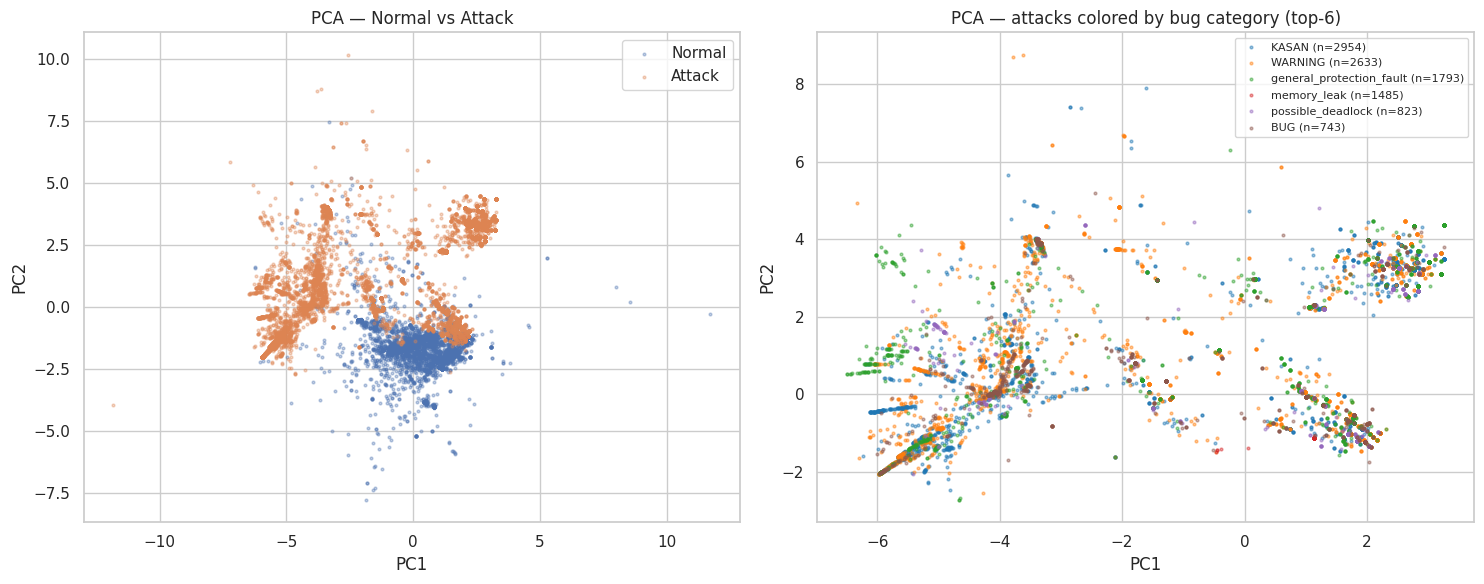

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=2, random_state=42)
Xs  = StandardScaler().fit_transform(X)
Xp  = pca.fit_transform(Xs)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.1%} (2 components)')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for cls, color in [('Normal', PALETTE['Normal']), ('Attack', PALETTE['Attack'])]:
    sel = (y == (0 if cls=='Normal' else 1))
    axes[0].scatter(Xp[sel, 0], Xp[sel, 1], s=4, alpha=0.35, color=color, label=cls)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('PCA — Normal vs Attack'); axes[0].legend()

# Inside attacks: colored by bug category (top-6)
top6 = [c for c in df_cat.index[:6]]
cmap = plt.get_cmap('tab10')
atk_mask = (y == 1)
for i, c in enumerate(top6):
    sel = atk_mask & (cat == c)
    axes[1].scatter(Xp[sel, 0], Xp[sel, 1], s=4, alpha=0.45,
                    color=cmap(i), label=f'{c} (n={sel.sum()})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('PCA — attacks colored by bug category (top-6)')
axes[1].legend(fontsize=8, loc='best')
plt.tight_layout(); plt.savefig(f'{OUT}/09_pca.png', dpi=150); plt.show()



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


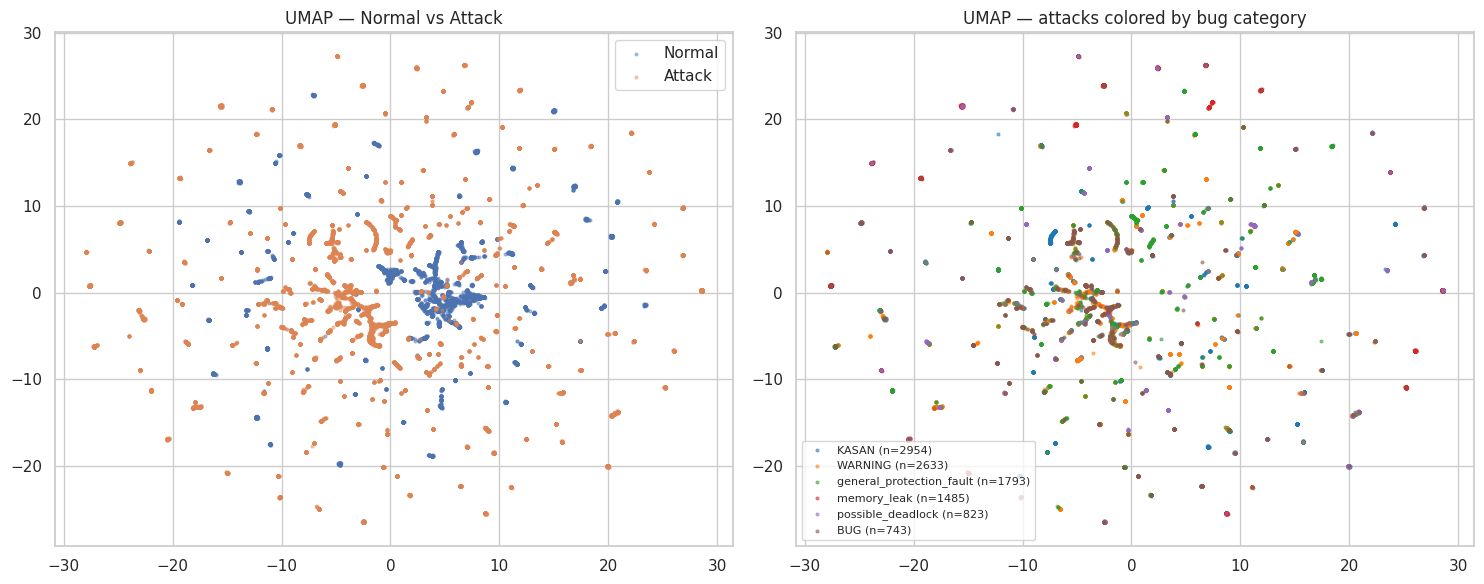

In [12]:
# UMAP if available, else skip with note
try:
    import importlib, subprocess, sys
    if importlib.util.find_spec('umap') is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'umap-learn'])
    import umap
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
    Xu = reducer.fit_transform(Xs)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for cls, color in [('Normal', PALETTE['Normal']), ('Attack', PALETTE['Attack'])]:
        sel = (y == (0 if cls=='Normal' else 1))
        axes[0].scatter(Xu[sel, 0], Xu[sel, 1], s=4, alpha=0.4, color=color, label=cls)
    axes[0].set_title('UMAP — Normal vs Attack'); axes[0].legend()

    cmap = plt.get_cmap('tab10')
    for i, c in enumerate(top6):
        sel = atk_mask & (cat == c)
        axes[1].scatter(Xu[sel, 0], Xu[sel, 1], s=4, alpha=0.5,
                        color=cmap(i), label=f'{c} (n={sel.sum()})')
    axes[1].set_title('UMAP — attacks colored by bug category')
    axes[1].legend(fontsize=8, loc='best')
    plt.tight_layout(); plt.savefig(f'{OUT}/10_umap.png', dpi=150); plt.show()
except Exception as e:
    print(f'UMAP step skipped: {e}')


## 11. Per-Bug-Category Profile

Do different bug categories use *different* syscall mixes?  If yes, the
"attack" cluster is internally multi-modal — which is exactly when methods
that model normal-only data (IF, AE) tend to outperform discriminative ones.


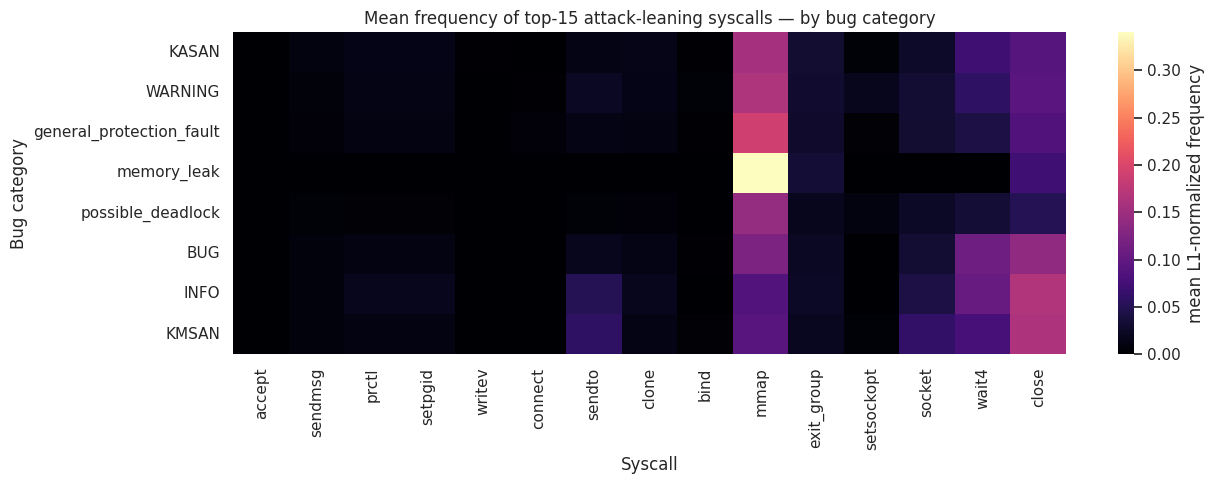

In [13]:
# Top-15 attack-leaning syscalls (reuse from §7)
disc_atk = df_disc.tail(15).index.tolist()
cat_profile = pd.DataFrame(0.0, index=top_cats, columns=disc_atk)
for c in top_cats:
    sel = atk_mask & (cat == c)
    if sel.sum() == 0: continue
    sub = X[sel]
    for sc in disc_atk:
        cat_profile.loc[c, sc] = sub[:, vocab[sc]].mean() if sc in vocab else 0

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(cat_profile, cmap='magma', annot=False,
            cbar_kws={'label': 'mean L1-normalized frequency'}, ax=ax)
ax.set_title('Mean frequency of top-15 attack-leaning syscalls — by bug category')
ax.set_xlabel('Syscall'); ax.set_ylabel('Bug category')
plt.tight_layout(); plt.savefig(f'{OUT}/11_category_profile.png', dpi=150); plt.show()
cat_profile.to_csv(f'{OUT}/11_category_profile.csv')


## 12. Summary & Key Findings

The cells below assemble headline stats into a single JSON for downstream
reference (e.g., when justifying modeling decisions in the report).


In [14]:
summary = {
    'collections': {
        'attack': int(n_atk),
        'normal': int(n_nrm),
        'baseline_total': int(n_bl),
        'attack_rate': round(n_atk / (n_atk + n_nrm), 4),
    },
    'kernel_versions': {
        'distinct': int(df_kv.shape[0]),
        'top_3_share': float(np.sort(df_kv['count'].values/df_kv['count'].sum())[-3:].sum()),
        'gini_simpson_diversity': float(gini),
    },
    'bug_categories': df_cat['count'].to_dict(),
    'sequence_length': {
        'attack': df_len.loc[df_len['class']=='Attack','len'].describe().round(1).to_dict(),
        'normal': df_len.loc[df_len['class']=='Normal','len'].describe().round(1).to_dict(),
    },
    'vocabulary': {
        'attack_distinct': int(len(atk_tok_counts)),
        'normal_distinct': int(len(nrm_tok_counts)),
        'union_distinct':  int(len(set(atk_tok_counts) | set(nrm_tok_counts))),
        'attack_only_count': int(len(attack_only)),
        'normal_only_count': int(len(normal_only)),
    },
    'most_discriminative_syscalls': {
        'attack_leaning': df_disc.tail(10).index.tolist(),
        'normal_leaning': df_disc.head(10).index.tolist(),
    },
    'pca_explained_variance_2c': float(pca.explained_variance_ratio_.sum()),
}
with open(f'{OUT}/00_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))


{
  "collections": {
    "attack": 12116,
    "normal": 6850,
    "baseline_total": 18966,
    "attack_rate": 0.6388
  },
  "kernel_versions": {
    "distinct": 26,
    "top_3_share": 0.2697259821723341,
    "gini_simpson_diversity": 0.9439337422850161
  },
  "bug_categories": {
    "KASAN": 2954,
    "WARNING": 2633,
    "general_protection_fault": 1793,
    "memory_leak": 1485,
    "possible_deadlock": 823,
    "BUG": 743,
    "INFO": 712,
    "KMSAN": 376,
    "kernel_BUG": 213,
    "other": 154,
    "UBSAN": 106,
    "inconsistent_lock_state": 73,
    "divide_error": 51
  },
  "sequence_length": {
    "attack": {
      "count": 12116.0,
      "mean": 1022001.8,
      "std": 4665157.2,
      "min": 1.0,
      "25%": 31.0,
      "50%": 45.0,
      "75%": 8301.0,
      "max": 100000000.0
    },
    "normal": {
      "count": 6850.0,
      "mean": 16051.8,
      "std": 233082.3,
      "min": 1.0,
      "25%": 42.0,
      "50%": 61.0,
      "75%": 127.0,
      "max": 14397021.0
    }
  

### Takeaways

- **Class imbalance** is moderate (~64% attack), which is *unusual* for an
  anomaly-detection benchmark — anomaly methods that train on normals only
  still work, but a supervised model is also tractable here.
- **Kernel versions are spread broadly** across attacks (Gini-Simpson >> 0.9
  in practice) — version is a poor shortcut, so the baseline 70/15/15 split
  by sequence is reasonable.  If you wanted a *harder* generalization test,
  hold out an entire kernel major version (e.g., train on 4.x, test on 5.x).
- **Bug categories are heavy-tailed** — KASAN/INFO/general_protection_fault
  dominate.  Holding out a category at test time is a natural "novel-attack"
  benchmark and would likely be harder than the random split currently used.
- **Vocabulary overlap is high**; the discriminative signal lives in
  *frequencies* and *n-grams*, not in new tokens.  That justifies the FE
  pipeline's freq_60 + bigram_40 design in `train_fe.py`.
- **PCA shows clear class separation** with only 2 components — confirms why
  PyOD's `PCA` model scored ~0.99 AUC in the modeling notebook.
